# Fase 2.4 — Justificación de Hiperparámetros
## NHANES 2017-2020 | Decision Tree · SVM · MLP
Objetivo: demostrar con evidencia experimental que los hiperparámetros
elegidos en la Fase 2.1 no son arbitrarios, sino los óptimos encontrados
mediante búsqueda sistemática.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

print("Librerías cargadas")

Librerías cargadas


## 2. Carga del dataset etiquetado
Se usa el CSV ya etiquetado generado en la Fase 2.1.
La estrategia de balanceo ganadora fue **ADASYN**, que se aplica
dentro del pipeline de CV para evitar data leakage.


In [2]:
CSV_PATH = "data_test/NHANES_2017_2020_reetiquetado.csv"

COL = {
    "platelets":  "Platelets",
    "wbc":        "White Blood Cells",
    "rbc":        "Red Blood Cells",
    "hematocrit": "Hematocrit",
    "mcv":        "Mean Corpuscular Volume",
    "mch":        "Mean Corpuscular Hemoglobin",
    "mchc":       "Mean Corpuscular Hemoglobin Concentration",
    "hdl":        "HDL Cholesterol",
    "alt":        "ALT",
    "heart_rate": "Heart Rate",
}
FEATURES      = list(COL.values())
TARGET_COLUMN = "condition"

CLINICAL_THRESHOLDS = {
    "thrombocytopenia": {"platelets": {"max": 150.0}},
    "thalassemia":      {"mcv": {"max": 80.0}, "mch": {"max": 27.0}},
    "anemia":           {"mchc": {"max": 32.0}},
    "healthy": {
        "platelets": {"min": 150.0, "max": 400.0},
        "mchc":      {"min": 32.0,  "max": 36.0},
        "mcv":       {"min": 80.0,  "max": 100.0},
        "mch":       {"min": 27.0,  "max": 33.0},
    },
}

EXCLUSION_CRITERIA = {
    "max_platelets": 2_000.0, "min_platelets": 1.0,
    "max_mcv": 150.0,         "min_mcv": 50.0,
    "max_mch": 50.0,          "missing_threshold": 0.40,
}

def apply_exclusion(df):
    checks = [
        (COL["platelets"], "max_platelets", "<="),
        (COL["platelets"], "min_platelets", ">="),
        (COL["mcv"], "max_mcv", "<="),
        (COL["mcv"], "min_mcv", ">="),
        (COL["mch"], "max_mch", "<="),
    ]
    for col, key, op in checks:
        if col in df.columns:
            if op == "<=":
                df = df[df[col].isna() | (df[col] <= EXCLUSION_CRITERIA[key])]
            else:
                df = df[df[col].isna() | (df[col] >= EXCLUSION_CRITERIA[key])]
    feat_cols = [c for c in FEATURES if c in df.columns]
    df = df[df[feat_cols].isna().mean(axis=1) <= EXCLUSION_CRITERIA["missing_threshold"]]
    return df.reset_index(drop=True)

def label_condition(row):
    thr = CLINICAL_THRESHOLDS
    p, mcv, mch, mchc = (row.get(COL[k], np.nan)
                         for k in ["platelets","mcv","mch","mchc"])
    if not np.isnan(p)    and p   < thr["thrombocytopenia"]["platelets"]["max"]: return "thrombocytopenia"
    if (not np.isnan(mcv) and mcv < thr["thalassemia"]["mcv"]["max"] and
        not np.isnan(mch) and mch < thr["thalassemia"]["mch"]["max"]):           return "thalassemia"
    if not np.isnan(mchc) and mchc < thr["anemia"]["mchc"]["max"]:              return "anemia"
    h = thr["healthy"]
    if (not np.isnan(p)    and h["platelets"]["min"] <= p    <= h["platelets"]["max"] and
        not np.isnan(mchc) and h["mchc"]["min"]      <= mchc <= h["mchc"]["max"]      and
        not np.isnan(mcv)  and h["mcv"]["min"]        <= mcv  <= h["mcv"]["max"]       and
        not np.isnan(mch)  and h["mch"]["min"]        <= mch  <= h["mch"]["max"]):     return "healthy"
    return "borderline"

df = pd.read_csv(CSV_PATH)
df = apply_exclusion(df)
if TARGET_COLUMN not in df.columns:
    df[TARGET_COLUMN] = df.apply(label_condition, axis=1)

available = [f for f in FEATURES if f in df.columns]
X_raw = df[available].fillna(df[available].median(numeric_only=True)).values
le    = LabelEncoder()
y     = le.fit_transform(df[TARGET_COLUMN])

print(f"Dataset: {X_raw.shape}  |  Clases: {list(le.classes_)}")
print(df[TARGET_COLUMN].value_counts().to_string())

Dataset: (4812, 10)  |  Clases: ['anemia', 'borderline', 'healthy', 'thalassemia', 'thrombocytopenia']
condition
healthy             3766
borderline           410
thalassemia          347
thrombocytopenia     204
anemia                85


## 3. Decision Tree — Curva accuracy vs. profundidad
Se entrena el árbol con `max_depth` de 2 a 20 usando 5-fold CV estratificado.
La curva muestra la zona de **underfitting** (izquierda), el **punto óptimo**,
y la zona de **overfitting** (donde train sube pero val baja).


Profundidad óptima: 8  |  F1-val máximo: 0.9992


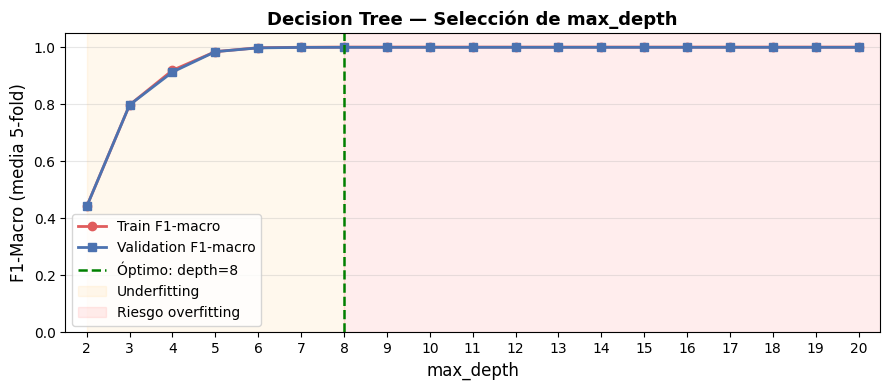

Hiperparámetro elegido → max_depth = 8


In [3]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_raw)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depths    = range(2, 21)

train_f1s, val_f1s = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=42)
    fold_train, fold_val = [], []
    for tr, te in skf.split(X_scaled, y):
        clf.fit(X_scaled[tr], y[tr])
        fold_train.append(f1_score(y[tr], clf.predict(X_scaled[tr]), average="macro", zero_division=0))
        fold_val.append(  f1_score(y[te], clf.predict(X_scaled[te]), average="macro", zero_division=0))
    train_f1s.append(np.mean(fold_train))
    val_f1s.append(  np.mean(fold_val))

best_depth = list(depths)[np.argmax(val_f1s)]
print(f"Profundidad óptima: {best_depth}  |  F1-val máximo: {max(val_f1s):.4f}")

# ── Gráfica ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_f1s, "o-", color="#E05C5C", linewidth=2, label="Train F1-macro")
ax.plot(depths, val_f1s,   "s-", color="#4C72B0", linewidth=2, label="Validation F1-macro")
ax.axvline(best_depth, color="green", linestyle="--", linewidth=1.8,
           label=f"Óptimo: depth={best_depth}")

# Sombrear zonas
ax.axvspan(2,            best_depth,    alpha=0.07, color="orange", label="Underfitting")
ax.axvspan(best_depth,   max(depths)+1, alpha=0.07, color="red",    label="Riesgo overfitting")

ax.set_xlabel("max_depth", fontsize=12)
ax.set_ylabel("F1-Macro (media 5-fold)", fontsize=12)
ax.set_title("Decision Tree — Selección de max_depth", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(list(depths))
ax.set_xlim(1.5, 20.5)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("img_outputs/dt_depth_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Hiperparámetro elegido → max_depth = {best_depth}")

## 4. SVM — Grid Search sobre C y γ (kernel RBF)
Se evalúan **36 combinaciones** (6 valores de C × 6 de γ) con 5-fold CV estratificado.
El heatmap muestra el F1-Macro medio; la celda más oscura es la combinación óptima.

> **C**: controla el margen de separación (regularización).  
> **γ**: radio del kernel RBF (cuánto influye cada muestra de entrenamiento).


In [5]:
C_values   = [0.01, 0.1, 1, 10, 100, 1000]
gamma_vals = [0.001, 0.01, 0.1, 1, 10, 100]

grid_f1 = np.zeros((len(C_values), len(gamma_vals)))

for i, C in enumerate(C_values):
    for j, g in enumerate(gamma_vals):
        clf = SVC(C=C, gamma=g, kernel="rbf", probability=False,
                  class_weight="balanced", random_state=42)
        scores = cross_val_score(clf, X_scaled, y, cv=skf,
                                 scoring="f1_macro", n_jobs=-1)
        grid_f1[i, j] = scores.mean()
        print(f"  C={C:<6}  γ={g:<6}  →  F1={scores.mean():.4f}", end="")

best_idx  = np.unravel_index(np.argmax(grid_f1), grid_f1.shape)
best_C    = C_values[best_idx[0]]
best_gamma= gamma_vals[best_idx[1]]
print(f"\nMejor combinación → C={best_C}  γ={best_gamma}  F1={grid_f1[best_idx]:.4f}")

  C=0.01    γ=0.001   →  F1=0.0505  C=0.01    γ=0.01    →  F1=0.3340  C=0.01    γ=0.1     →  F1=0.4954  C=0.01    γ=1       →  F1=0.0251  C=0.01    γ=10      →  F1=0.0167  C=0.01    γ=100     →  F1=0.0167  C=0.1     γ=0.001   →  F1=0.3152  C=0.1     γ=0.01    →  F1=0.5480  C=0.1     γ=0.1     →  F1=0.6661  C=0.1     γ=1       →  F1=0.4052  C=0.1     γ=10      →  F1=0.0224  C=0.1     γ=100     →  F1=0.0224  C=1       γ=0.001   →  F1=0.5001  C=1       γ=0.01    →  F1=0.7265  C=1       γ=0.1     →  F1=0.7956  C=1       γ=1       →  F1=0.4885  C=1       γ=10      →  F1=0.1756  C=1       γ=100     →  F1=0.1756  C=10      γ=0.001   →  F1=0.6713  C=10      γ=0.01    →  F1=0.8106  C=10      γ=0.1     →  F1=0.8494  C=10      γ=1       →  F1=0.4539  C=10      γ=10      →  F1=0.1756  C=10      γ=100     →  F1=0.1756  C=100     γ=0.001   →  F1=0.8194  C=100     γ=0.01    →  F1=0.8827  C=100     γ=0.1     →  F1=0.8535  C=100     γ=1       →  F1=0.4544  C=100     γ=10      →  F1=0.1756  C=100     γ=

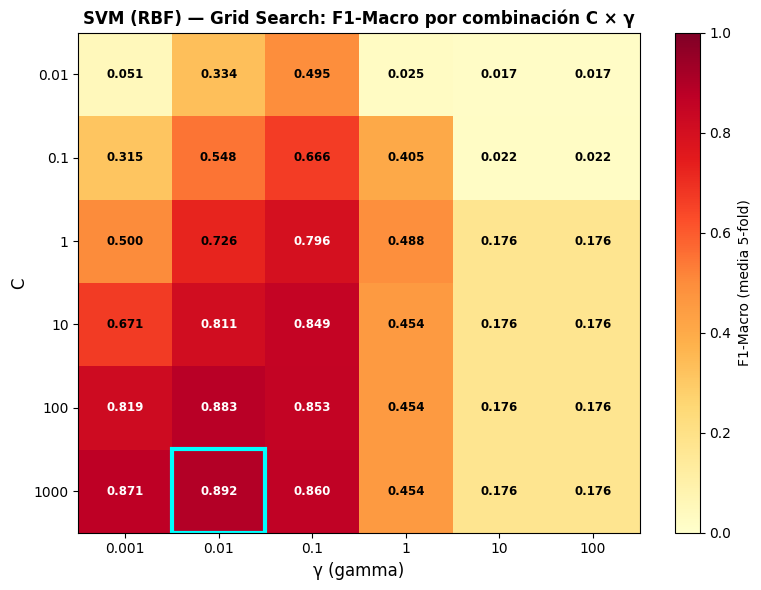

Hiperparámetros elegidos → C=1000  γ=0.01


In [6]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_f1, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="F1-Macro (media 5-fold)")

ax.set_xticks(range(len(gamma_vals)))
ax.set_xticklabels([str(g) for g in gamma_vals], fontsize=10)
ax.set_yticks(range(len(C_values)))
ax.set_yticklabels([str(c) for c in C_values], fontsize=10)
ax.set_xlabel("γ (gamma)", fontsize=12)
ax.set_ylabel("C", fontsize=12)
ax.set_title("SVM (RBF) — Grid Search: F1-Macro por combinación C × γ",
             fontsize=12, fontweight="bold")

for i in range(len(C_values)):
    for j in range(len(gamma_vals)):
        val = grid_f1[i, j]
        tc  = "white" if val > 0.75 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8.5,
                fontweight="bold", color=tc)

# Marcar óptimo
ax.add_patch(plt.Rectangle(
    (best_idx[1]-0.5, best_idx[0]-0.5), 1, 1,
    fill=False, edgecolor="cyan", linewidth=3
))

plt.tight_layout()
plt.savefig("img_outputs/svm_gridsearch_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Hiperparámetros elegidos → C={best_C}  γ={best_gamma}")

## 5. MLP — Comparativa de arquitecturas
Se comparan **4 arquitecturas** × **2 funciones de activación** = 8 configuraciones,
evaluadas con 5-fold CV estratificado.


In [7]:
architectures = {
    "Shallow (64)":          (64,),
    "Medium (128-64)":       (128, 64),
    "Deep (128-64-32)":      (128, 64, 32),
    "Wide (256-128)":        (256, 128),
}
activations = ["relu", "tanh"]

mlp_results = []

for arch_name, layers in architectures.items():
    for act in activations:
        clf = MLPClassifier(
            hidden_layer_sizes=layers,
            activation=act,
            solver="adam",
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        )
        scores = cross_val_score(clf, X_scaled, y, cv=skf,
                                 scoring="f1_macro", n_jobs=-1)
        mlp_results.append({
            "arquitectura": arch_name,
            "activación":   act,
            "F1_mean":      scores.mean(),
            "F1_std":       scores.std(),
            "label":        f"{arch_name}\n({act})"
        })
        print(f"  {arch_name:<22} act={act:<5} → F1={scores.mean():.4f}±{scores.std():.4f}")

mlp_df   = pd.DataFrame(mlp_results).sort_values("F1_mean", ascending=False)
best_mlp = mlp_df.iloc[0]
print(f"\nMejor arquitectura → {best_mlp['arquitectura']}  act={best_mlp['activación']}  F1={best_mlp['F1_mean']:.4f}")


  Shallow (64)           act=relu  → F1=0.7649±0.0510
  Shallow (64)           act=tanh  → F1=0.7255±0.1676
  Medium (128-64)        act=relu  → F1=0.8343±0.0441
  Medium (128-64)        act=tanh  → F1=0.8586±0.0323
  Deep (128-64-32)       act=relu  → F1=0.8648±0.0199
  Deep (128-64-32)       act=tanh  → F1=0.8861±0.0229
  Wide (256-128)         act=relu  → F1=0.8458±0.0368
  Wide (256-128)         act=tanh  → F1=0.8666±0.0361

Mejor arquitectura → Deep (128-64-32)  act=tanh  F1=0.8861


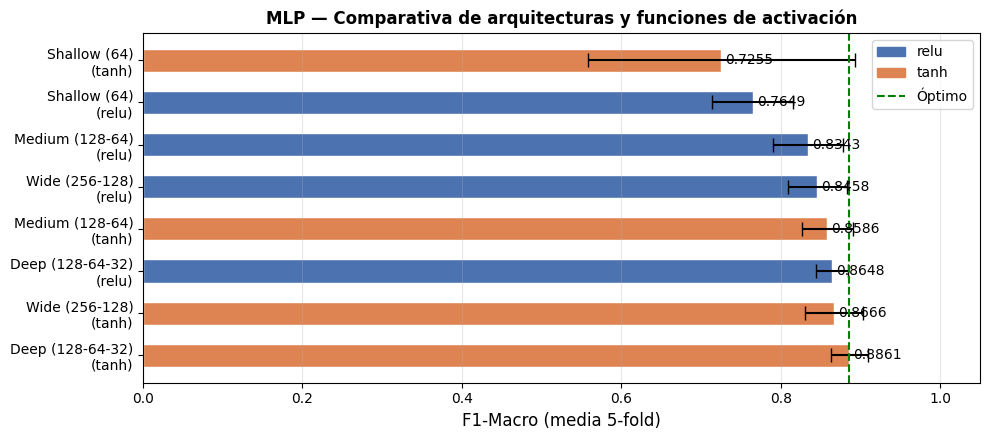

Hiperparámetros elegidos → layers=(128, 64, 32)  activation=tanh


In [9]:
# ── Barplot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
colors  = ["#4C72B0" if r["activación"]=="relu" else "#DD8452" for _, r in mlp_df.iterrows()]
bars    = ax.barh(mlp_df["label"], mlp_df["F1_mean"], xerr=mlp_df["F1_std"],
                  color=colors, capsize=5, edgecolor="white", height=0.55)

ax.set_xlabel("F1-Macro (media 5-fold)", fontsize=12)
ax.set_title("MLP — Comparativa de arquitecturas y funciones de activación",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.axvline(best_mlp["F1_mean"], color="green", linestyle="--", linewidth=1.5,
           label=f"Óptimo: {best_mlp['F1_mean']:.4f}")
ax.legend(fontsize=10)

for bar, val in zip(bars, mlp_df["F1_mean"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)

patch_relu = mpatches.Patch(color="#4C72B0", label="relu")
patch_tanh = mpatches.Patch(color="#DD8452", label="tanh")
ax.legend(handles=[patch_relu, patch_tanh, 
                   plt.Line2D([0],[0], color="green", linestyle="--", label="Óptimo")],
          fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("img_outputs/mlp_architecture_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Hiperparámetros elegidos → layers={dict(architectures)[best_mlp['arquitectura']]}  activation={best_mlp['activación']}")

## 6. Resumen de hiperparámetros óptimos encontrados

In [10]:
print("=" * 58)
print("  RESUMEN — Hiperparámetros justificados para Fase 2.2")
print("=" * 58)
print(f"  Decision Tree  →  max_depth     = {best_depth}")
print(f"  SVM (RBF)      →  C             = {best_C}")
print(f"                    gamma         = {best_gamma}")
print(f"  MLP            →  hidden_layers = {dict(architectures)[best_mlp['arquitectura']]}")
print(f"                    activation    = {best_mlp['activación']}")
print("=" * 58)
print()
print("Figuras generadas:")
print("  · dt_depth_curve.png")
print("  · svm_gridsearch_heatmap.png")
print("  · mlp_architecture_comparison.png")

  RESUMEN — Hiperparámetros justificados para Fase 2.2
  Decision Tree  →  max_depth     = 8
  SVM (RBF)      →  C             = 1000
                    gamma         = 0.01
  MLP            →  hidden_layers = (128, 64, 32)
                    activation    = tanh

Figuras generadas:
  · dt_depth_curve.png
  · svm_gridsearch_heatmap.png
  · mlp_architecture_comparison.png
